<a href="https://colab.research.google.com/github/AshrfCode/Anan-Tirgulem/blob/main/lab8_ex3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Standard scientific Python imports
import matplotlib.pyplot as plt
import random
import numpy as np

# Import dataset and classifiers
from sklearn import datasets, svm
from sklearn.model_selection import train_test_split

In [ ]:
# Plot  image samples
def plotSamples(data,rows,cols,trueLabels,predictedLabels=[]):
    fig, axs = plt.subplots(rows,cols)
    nDigits = data.shape[0]
    for i in range(rows):
        for j in range(cols):
            index = random.randint(0,nDigits-1)
            axs[i,j].imshow(data[index].reshape(8,8),cmap = 'gray')
            # remove axes titles
            axs[i,j].axis('off')
            if (np.any(predictedLabels)):
                axs[i,j].set_title('Predct: %i,  Real %i' % (predictedLabels[index], trueLabels[index]) ,fontdict={'fontsize': 10})
            else:
                axs[i,j].set_title('Real: %i' % trueLabels[index],fontdict={'fontsize': 10})
            # show the figure
    plt.show()

In [ ]:
# The digits dataset consisits of 8x8 images of digits
digits = datasets.load_digits()
data = digits.data
trueLabels = digits.target

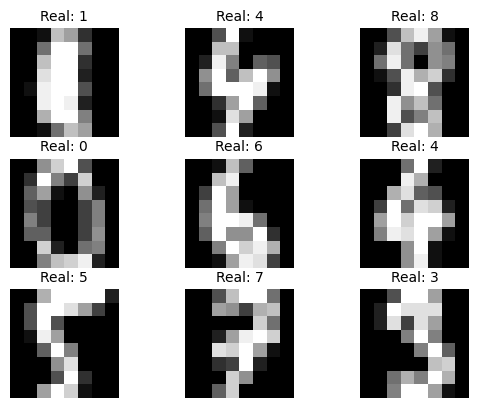

In [ ]:
rows = 3
cols = 3
plotSamples(data,rows,cols,trueLabels)

**Choose half of the images as a Training Set and the rest of the images as a Testing Set.**

In [ ]:
# Split data into train and test subsets
trainData, testData, trainLabels, testLabels = train_test_split(
    data, trueLabels, train_size= 0.5,stratify=trueLabels)

In [ ]:
# Train a support vector classifier and predict the test set
classifier = svm.SVC(kernel='rbf', gamma='scale')
classifier.fit(trainData, trainLabels)
predictedLabels = classifier.predict(testData)

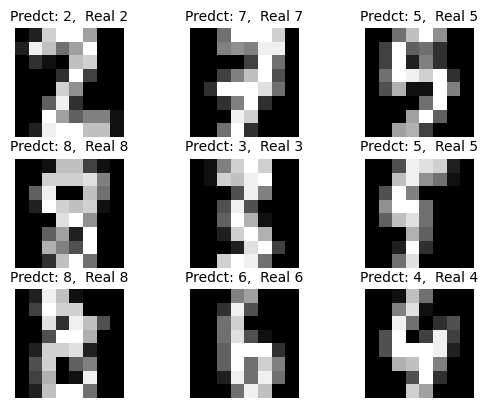

In [ ]:
plotSamples(testData,rows,cols,testLabels,predictedLabels)

# **Question 1**

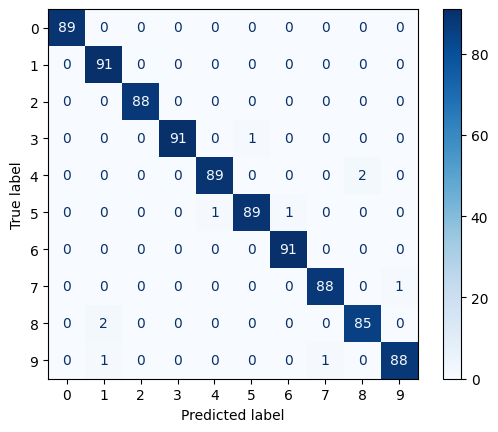


Error percentage per digit:
Digit 0: 0.00%
Digit 1: 0.00%
Digit 2: 0.00%
Digit 3: 1.09%
Digit 4: 2.20%
Digit 5: 2.20%
Digit 6: 0.00%
Digit 7: 1.12%
Digit 8: 2.30%
Digit 9: 2.22%
Model Accuracy: 98.89%


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix
cm = confusion_matrix(testLabels, predictedLabels)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

# Error percentage per digit
row_totals = cm.sum(axis=1)
correct = np.diag(cm)
error_pct = (1 - correct / row_totals) * 100

print("\nError percentage per digit:")
for d in range(10):
    print(f"Digit {d}: {error_pct[d]:.2f}%")

# Count how many predictions matched the true labels
correct_predictions = 0
for i in range(len(testLabels)):
    if testLabels[i] == predictedLabels[i]:
        correct_predictions += 1

total_predictions = len(testLabels)

# Calculate the accuracy as a percentage
accuracy = (correct_predictions / total_predictions) * 100

print(f"Model Accuracy: {accuracy:.2f}%")

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import confusion_matrix

# Assuming 'data' and 'trueLabels' are your original, clean variables
num_runs = 3
num_classes = 10

total_errors = np.zeros(num_classes)
total_counts = np.zeros(num_classes)

print("=== Part 1: Calculating Final Averages on Clean Data ===")

for i in range(num_runs):
    # 1. Create split on the CLEAN data
    X_train, X_test, y_train, y_test = train_test_split(
        data,
        trueLabels,
        test_size=0.50,
        stratify=trueLabels,
        random_state=np.random.randint(0, 1000)
    )

    # 2. Train and Predict
    clf = svm.SVC(kernel='rbf', gamma='scale')
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # 3. Create the Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=range(10))

    # 4. Accumulate counts for the final average
    row_totals = cm.sum(axis=1)
    correct = np.diag(cm)

    for d in range(num_classes):
        total_errors[d] += (row_totals[d] - correct[d])
        total_counts[d] += row_totals[d]

# 5. Print the final average
print("\n" + "="*40)
print("FINAL RESULTS (CLEAN DATA): Average % Error per Digit over 3 runs")
print("="*40)

for d in range(num_classes):
    if total_counts[d] > 0:
        avg_error = (total_errors[d] / total_counts[d]) * 100
        print(f"Digit {d}: {avg_error:.2f}%")
    else:
        print(f"Digit {d}: No data")

=== Part 1: Calculating Final Averages on Clean Data ===

FINAL RESULTS (CLEAN DATA): Average % Error per Digit over 3 runs
Digit 0: 0.37%
Digit 1: 0.37%
Digit 2: 0.00%
Digit 3: 2.90%
Digit 4: 1.10%
Digit 5: 2.56%
Digit 6: 0.73%
Digit 7: 0.37%
Digit 8: 3.45%
Digit 9: 3.33%


In [ ]:
# Count how many predictions matched the true labels
correct_predictions = 0
for i in range(len(testLabels)):
    if testLabels[i] == predictedLabels[i]:
        correct_predictions += 1

total_predictions = len(testLabels)

# Calculate the accuracy as a percentage
accuracy = (correct_predictions / total_predictions) * 100
print(f"Model Accuracy: {accuracy:.2f}%")

Model Accuracy: 98.89%


# **Question 2**

In [ ]:
import numpy as np

def create_noisy_dataset(original_data):
    # 1. Build a new dataset so we don't destroy the original
    noisy_data = original_data.copy()

    rng = np.random.default_rng()

    for i in range(noisy_data.shape[0]):
        # 2. Select between 0 and 12 pixels (13 is exclusive)
        k = rng.integers(0, 13)

        if k == 0:
            continue

        # Select 'k' unique indices out of 64 pixels
        idx = rng.choice(64, size=k, replace=False)

        # 3. Invert the selected pixels in the 0-15 range
        noisy_data[i, idx] = 15 - noisy_data[i, idx]

    return noisy_data

# Question **3**

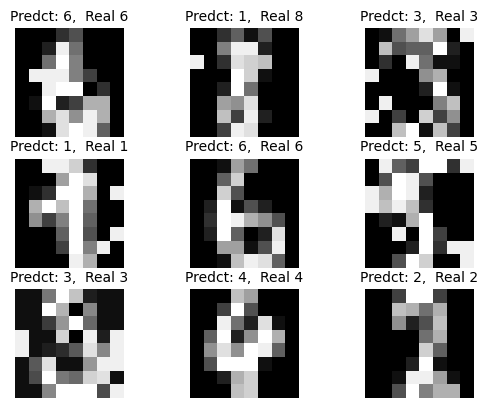

In [ ]:
# 1. call the function from Q2 to create the noisy dataset
X_noisy = create_noisy_dataset(data)

# 2. Split the new noisy data into training and testing sets
X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(
    X_noisy, trueLabels, test_size=0.50, stratify=trueLabels
)

# 3. Train a brand new SVM classifier on the noisy training data
clf_noisy = svm.SVC(kernel='rbf', gamma='scale')
clf_noisy.fit(X_tr_n, y_tr_n)

# 4. Generate the predictions for the noisy test data
y_pr_n = clf_noisy.predict(X_te_n)

# 5. Now plot the 9 samples
plotSamples(X_te_n, 3, 3, y_te_n, y_pr_n)

# **Question 4**

=== Part 4: 3 Runs on Noisy Dataset ===

--- Run 1 ---


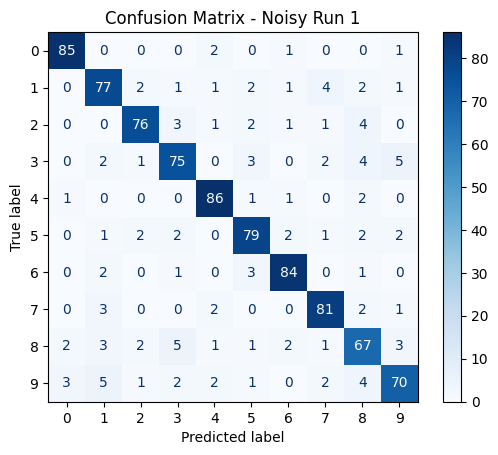

Error percentage per digit:
Digit 0: 4.49%
Digit 1: 15.38%
Digit 2: 13.64%
Digit 3: 18.48%
Digit 4: 5.49%
Digit 5: 13.19%
Digit 6: 7.69%
Digit 7: 8.99%
Digit 8: 22.99%
Digit 9: 22.22%
Model Accuracy: 86.76%

--- Run 2 ---


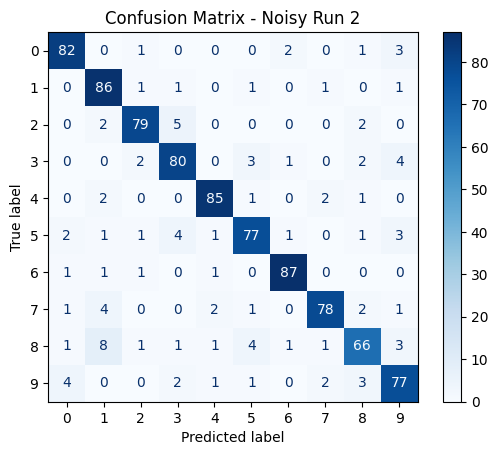

Error percentage per digit:
Digit 0: 7.87%
Digit 1: 5.49%
Digit 2: 10.23%
Digit 3: 13.04%
Digit 4: 6.59%
Digit 5: 15.38%
Digit 6: 4.40%
Digit 7: 12.36%
Digit 8: 24.14%
Digit 9: 14.44%
Model Accuracy: 88.65%

--- Run 3 ---


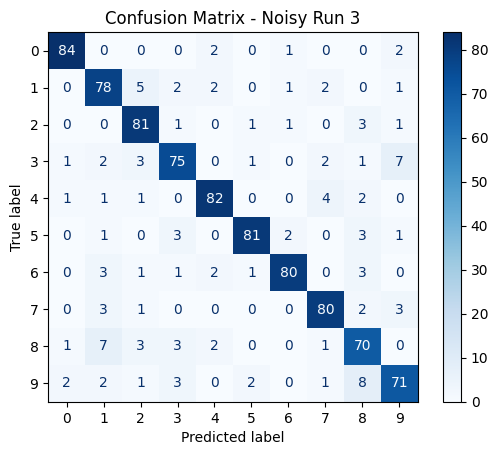

Error percentage per digit:
Digit 0: 5.62%
Digit 1: 14.29%
Digit 2: 7.95%
Digit 3: 18.48%
Digit 4: 9.89%
Digit 5: 10.99%
Digit 6: 12.09%
Digit 7: 10.11%
Digit 8: 19.54%
Digit 9: 21.11%
Model Accuracy: 86.99%

FINAL RESULTS: Average % Error per Digit over 3 runs
Digit 0: 5.99%
Digit 1: 11.72%
Digit 2: 10.61%
Digit 3: 16.67%
Digit 4: 7.33%
Digit 5: 13.19%
Digit 6: 8.06%
Digit 7: 10.49%
Digit 8: 22.22%
Digit 9: 19.26%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming X_noisy and trueLabels are already in your notebook
num_runs = 3
num_classes = 10

# Tracking arrays for the final average calculation
total_errors_per_digit = np.zeros(num_classes)
total_counts_per_digit = np.zeros(num_classes)

print("=== Part 4: 3 Runs on Noisy Dataset ===")

for i in range(num_runs):
    print(f"\n--- Run {i+1} ---")

    # 1. Create a new random 50/50 split on the NOISY data
    X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(
        X_noisy,
        trueLabels,
        test_size=0.50,
        stratify=trueLabels,
        random_state=np.random.randint(0, 1000)
    )

    # 2. Train and Predict
    clf_noisy = svm.SVC(kernel='rbf', gamma='scale')
    clf_noisy.fit(X_tr_n, y_tr_n)
    y_pr_n = clf_noisy.predict(X_te_n)

    # 3. Create the Confusion Matrix
    cm = confusion_matrix(y_te_n, y_pr_n, labels=range(10))

    # 4. Plot the beautiful visual matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - Noisy Run {i+1}")
    plt.show() # This will render the plot directly in Colab

    # 5. Calculate per-run stats using your clean NumPy logic
    row_totals = cm.sum(axis=1)
    correct = np.diag(cm)

    # Handle division by zero just in case a row is empty
    with np.errstate(divide='ignore', invalid='ignore'):
        error_pct = np.nan_to_num((1 - correct / row_totals) * 100)

    print("Error percentage per digit:")
    for d in range(10):
        print(f"Digit {d}: {error_pct[d]:.2f}%")

    accuracy = (np.sum(correct) / np.sum(row_totals)) * 100
    print(f"Model Accuracy: {accuracy:.2f}%")

    # 6. Accumulate counts for the final average requirement
    for d in range(num_classes):
        total_errors_per_digit[d] += (row_totals[d] - correct[d])
        total_counts_per_digit[d] += row_totals[d]

# 7. Print the final average required by the assignment
print("\n" + "="*40)
print("FINAL RESULTS: Average % Error per Digit over 3 runs")
print("="*40)

for d in range(num_classes):
    if total_counts_per_digit[d] > 0:
        avg_error = (total_errors_per_digit[d] / total_counts_per_digit[d]) * 100
        print(f"Digit {d}: {avg_error:.2f}%")
    else:
        print(f"Digit {d}: No data")

# **Question 5**

In [ ]:
def plot_custom_digit(digit, is_true_pred, X_test, y_test, y_pred, ax):
    """
    Plots a specific digit based on whether we are looking for a true or false prediction.
    - True predictions: Green
    - False predictions: Red
    - Fallback (False not found): Yellow
    """
    digit = int(digit)

    if is_true_pred:
        # Look for a TRUE prediction
        indices = np.where((y_test == digit) & (y_pred == digit))[0]
        if len(indices) > 0:
            idx = random.choice(indices)
            img = X_test[idx].reshape(8, 8)
            ax.imshow(img, cmap='Greens')
            ax.set_title(f"T={digit}, P={digit}", fontsize=10)
        else:
            ax.axis('off') # Hide the subplot if no match is found

    else:
        # Look for a FALSE prediction
        indices = np.where((y_test == digit) & (y_pred != digit))[0]
        if len(indices) > 0:
            idx = random.choice(indices)
            predicted_val = y_pred[idx]
            img = X_test[idx].reshape(8, 8)
            ax.imshow(img, cmap='Reds')
            ax.set_title(f"T={digit}, P={predicted_val}", fontsize=10)
        else:
            # FALLBACK: False prediction not found, plot a true predicted digit in yellow
            fallback_indices = np.where((y_test == digit) & (y_pred == digit))[0]
            if len(fallback_indices) > 0:
                idx = random.choice(fallback_indices)
                img = X_test[idx].reshape(8, 8)
                ax.imshow(img, cmap='Wistia') # 'Wistia' is a standard yellow/orange colormap
                ax.set_title(f"T={digit}, P=N", fontsize=10)
            else:
                ax.axis('off')

    # Ensure axes lines/ticks are turned off for a clean look
    ax.axis('off')

# **Question 6**

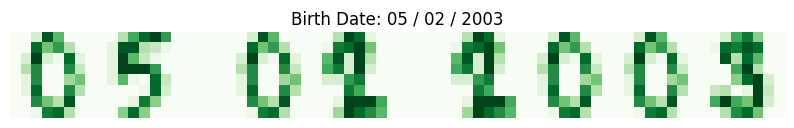

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Birth date digits (15 / 08 / 1998)
day_digits = [0, 5]
month_digits = [0, 2]
year_digits = [2, 0, 0, 3]

def get_correct_prediction_array(target_digit):
    """Extracts the 8x8 array of a correctly predicted digit using logic from section 6."""
    target_digit = int(target_digit)
    for i in range(len(testLabels)):
        if testLabels[i] == target_digit and predictedLabels[i] == target_digit:
            return testData[i].reshape(8, 8)

    # Fallback in case a specific digit prediction doesn't exist
    return np.zeros((8, 8))

# Gather the 8x8 images for each segment
day_images = [get_correct_prediction_array(d) for d in day_digits]
month_images = [get_correct_prediction_array(d) for d in month_digits]
year_images = [get_correct_prediction_array(d) for d in year_digits]

# Concatenate the arrays for day, month, and year separately
day_concat = np.hstack(day_images)
month_concat = np.hstack(month_images)
year_concat = np.hstack(year_images)

# Create a small blank spacer (8x4 pixels) to separate the segments visually
spacer = np.zeros((8, 4))

# Concatenate everything into one single line
full_date_concat = np.hstack((day_concat, spacer, month_concat, spacer, year_concat))

# Plot the final concatenated image in green
plt.figure(figsize=(10, 3))
plt.imshow(full_date_concat, cmap="Greens")
plt.title("Birth Date: 05 / 02 / 2003")
plt.axis("off")
plt.show()

# **Question 7**

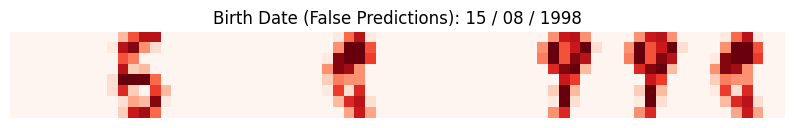

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Birth date digits (15 / 08 / 1998)
day_digits = [1, 5]
month_digits = [0, 8]
year_digits = [1, 9, 9, 8]

def get_false_prediction_array(target_digit):
    """Extracts the 8x8 array of an incorrectly predicted digit."""
    target_digit = int(target_digit)
    for i in range(len(testLabels)):
        # Look for a true label that matches, but a prediction that is wrong
        if testLabels[i] == target_digit and predictedLabels[i] != target_digit:
            return testData[i].reshape(8, 8)

    # Fallback in case no false prediction exists for this specific digit
    return np.zeros((8, 8))

# Gather the 8x8 images for false predictions
day_images_false = [get_false_prediction_array(d) for d in day_digits]
month_images_false = [get_false_prediction_array(d) for d in month_digits]
year_images_false = [get_false_prediction_array(d) for d in year_digits]

# Concatenate the arrays for day, month, and year separately
day_concat_false = np.hstack(day_images_false)
month_concat_false = np.hstack(month_images_false)
year_concat_false = np.hstack(year_images_false)

# Create a small blank spacer (8x4 pixels) to separate the segments visually
spacer = np.zeros((8, 4))

# Concatenate everything into one single line
full_date_concat_false = np.hstack((day_concat_false, spacer, month_concat_false, spacer, year_concat_false))

# Plot the final concatenated image in red
plt.figure(figsize=(10, 3))
plt.imshow(full_date_concat_false, cmap="Reds")
plt.title("Birth Date (False Predictions): 15 / 08 / 1998")
plt.axis("off")
plt.show()

Q2-6

--- Q4: Plotting 9 Samples from Noisy Dataset ---


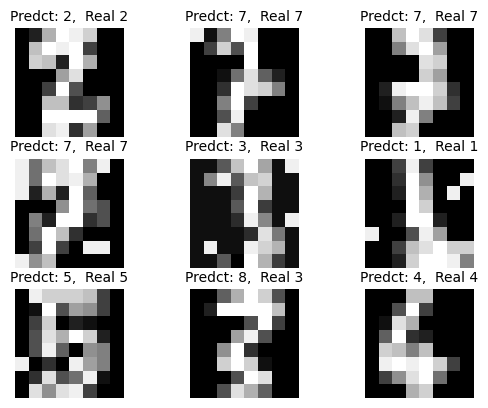


--- Q5: Noisy Dataset Evaluation (3 Runs) ---

Noisy Run 1 - Overall Accuracy: 87.10%
Digit 0 Error Rate: 6.74%
Digit 1 Error Rate: 15.38%
Digit 2 Error Rate: 6.82%
Digit 3 Error Rate: 16.30%
Digit 4 Error Rate: 10.99%
Digit 5 Error Rate: 16.48%
Digit 6 Error Rate: 5.49%
Digit 7 Error Rate: 7.87%
Digit 8 Error Rate: 25.29%
Digit 9 Error Rate: 17.78%

Noisy Run 2 - Overall Accuracy: 88.10%
Digit 0 Error Rate: 2.25%
Digit 1 Error Rate: 10.99%
Digit 2 Error Rate: 11.36%
Digit 3 Error Rate: 22.83%
Digit 4 Error Rate: 6.59%
Digit 5 Error Rate: 12.09%
Digit 6 Error Rate: 7.69%
Digit 7 Error Rate: 10.11%
Digit 8 Error Rate: 20.69%
Digit 9 Error Rate: 14.44%

Noisy Run 3 - Overall Accuracy: 88.32%
Digit 0 Error Rate: 5.62%
Digit 1 Error Rate: 8.79%
Digit 2 Error Rate: 12.50%
Digit 3 Error Rate: 15.22%
Digit 4 Error Rate: 4.40%
Digit 5 Error Rate: 10.99%
Digit 6 Error Rate: 5.49%
Digit 7 Error Rate: 10.11%
Digit 8 Error Rate: 25.29%
Digit 9 Error Rate: 18.89%


In [ ]:
import copy
import random
from sklearn.metrics import confusion_matrix, accuracy_score

# Q2: Function to inverse randomly 0-12 pixels
def create_noisy_dataset(original_data):
    noisy_data = copy.deepcopy(original_data)
    for i in range(noisy_data.shape[0]):
        num_pixels = random.randint(0, 12)
        # 8x8 image = 64 total pixels
        indices = random.sample(range(64), num_pixels)
        for idx in indices:
            # Inverse the pixel in the 0-15 range
            noisy_data[i, idx] = 15 - noisy_data[i, idx]
    return noisy_data

print("--- Q4: Plotting 9 Samples from Noisy Dataset ---")
# Q3 & Q4: Generate noisy set, train, and plot 9 samples
X_noisy_sample = create_noisy_dataset(data)
X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(X_noisy_sample, trueLabels, test_size=0.50, stratify=trueLabels)

clf_noisy = svm.SVC(kernel='rbf', gamma='scale')
clf_noisy.fit(X_tr_n, y_tr_n)
y_pr_n = clf_noisy.predict(X_te_n)

# Re-using the plotSamples function from the original notebook
plotSamples(X_te_n, 3, 3, y_te_n, y_pr_n)

print("\n--- Q5: Noisy Dataset Evaluation (3 Runs) ---")
# Q5: Run the model 3 times with new splits and new random data sets
for run in range(3):
    X_noisy = create_noisy_dataset(data)
    X_train, X_test, y_train, y_test = train_test_split(
        X_noisy, trueLabels, test_size=0.50, stratify=trueLabels
    )

    clf = svm.SVC(kernel='rbf', gamma='scale')
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\nNoisy Run {run + 1} - Overall Accuracy: {acc * 100:.2f}%")
    for digit in range(10):
        total_instances = np.sum(cm[digit, :])
        correct_predictions = cm[digit, digit]
        if total_instances > 0:
            error_rate = ((total_instances - correct_predictions) / total_instances) * 100
            print(f"Digit {digit} Error Rate: {error_rate:.2f}%")

7

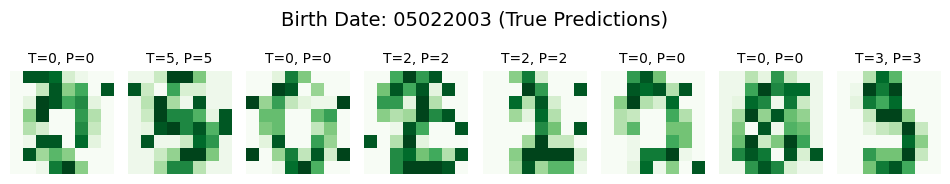

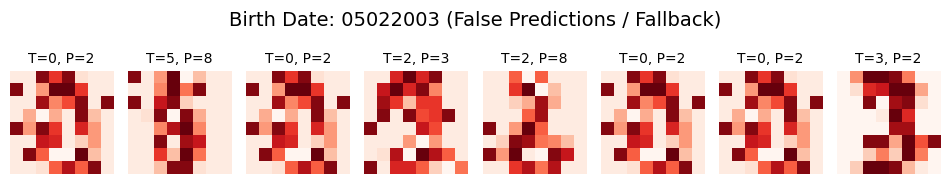

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Task 23-26: Function to plot custom digit based on prediction accuracy
def plot_custom_digit(digit, is_true_pred, X_test, y_test, y_pred, ax):
    digit = int(digit)

    if is_true_pred:
        # Look for a true prediction
        indices = np.where((y_test == digit) & (y_pred == digit))[0]
        if len(indices) > 0:
            idx = random.choice(indices)
            img = X_test[idx].reshape(8, 8)
            ax.imshow(img, cmap='Greens')
            ax.set_title(f"T={digit}, P={digit}", fontsize=10)
        else:
            ax.axis('off')

    else:
        # Look for a false prediction
        indices = np.where((y_test == digit) & (y_pred != digit))[0]
        if len(indices) > 0:
            idx = random.choice(indices)
            predicted_val = y_pred[idx]
            img = X_test[idx].reshape(8, 8)
            ax.imshow(img, cmap='Reds')
            ax.set_title(f"T={digit}, P={predicted_val}", fontsize=10)
        else:
            # Fallback: False prediction not found, plot true predicted in yellow
            fallback_indices = np.where((y_test == digit) & (y_pred == digit))[0]
            if len(fallback_indices) > 0:
                idx = random.choice(fallback_indices)
                img = X_test[idx].reshape(8, 8)
                ax.imshow(img, cmap='Wistia') # Wistia is a yellow colormap
                ax.set_title(f"T={digit}, P=N", fontsize=10)
            else:
                ax.axis('off')

    ax.axis('off')

# Set your birth date here (Day, Month, Year)
birth_date = "05022003"

# Tasks 27-28: Plot Birth Date with True Predictions
fig, axes = plt.subplots(1, len(birth_date), figsize=(len(birth_date)*1.2, 2))
fig.suptitle(f"Birth Date: {birth_date} (True Predictions)", fontsize=14)

for i, ch in enumerate(birth_date):
    # Utilizing the X_te_n, y_te_n, and y_pr_n variables from your noisy dataset split
    plot_custom_digit(int(ch), True, X_te_n, y_te_n, y_pr_n, axes[i])

plt.tight_layout()
plt.show()

# Tasks 29-30: Plot Birth Date with False Predictions (or Yellow Fallback)
fig, axes = plt.subplots(1, len(birth_date), figsize=(len(birth_date)*1.2, 2))
fig.suptitle(f"Birth Date: {birth_date} (False Predictions / Fallback)", fontsize=14)

for i, ch in enumerate(birth_date):
    plot_custom_digit(int(ch), False, X_te_n, y_te_n, y_pr_n, axes[i])

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Q7: Function to plot a specific digit based on prediction accuracy
def plot_custom_digit(digit, is_true_pred, X_test, y_test, y_pred, ax):
    """
    Plots a specific digit in Green (True), Red (False), or Yellow (Fallback).
    Requires the test data and predictions to be passed in.
    """
    if is_true_pred:
        # Look for a true prediction
        indices = np.where((y_test == digit) & (y_pred == digit))[0]
        cmap_color = 'Greens'
        title_str = f"T={digit}, P={digit}"
    else:
        # Look for a false prediction
        indices = np.where((y_test == digit) & (y_pred != digit))[0]
        cmap_color = 'Reds'
        title_str = "T={}, P={}" # Will format with actual prediction below

    if len(indices) > 0:
        # A match was found
        idx = random.choice(indices)
        predicted_val = y_pred[idx]
        img = X_test[idx].reshape(8, 8)

        ax.imshow(img, cmap=cmap_color)
        if not is_true_pred:
            ax.set_title(title_str.format(digit, predicted_val), fontsize=10)
        else:
            ax.set_title(title_str, fontsize=10)
    else:
        # Fallback: Condition not found, plot a true prediction in yellow
        fallback_indices = np.where((y_test == digit) & (y_pred == digit))[0]
        if len(fallback_indices) > 0:
            idx = random.choice(fallback_indices)
            img = X_test[idx].reshape(8, 8)
            ax.imshow(img, cmap='Wistia') # Yellow colormap
            ax.set_title(f"T={digit}, P=N", fontsize=10)

    ax.axis('off')